# MO coefficients discrepancies: He/cc-pvtz

In this noteboo I'll try to locate the discrepancies between my SCF implementation and the PySCF implementation, to try to understand the differences in MP2 energies computed:

- As a first example, I'll calculate the MP2 energy using my MO coefficients and the ones obtained by pyscf to check that the MP2 internal logic is actually correct. 
- After that I'll compare the MO coefficients and plot the relevant orbitals to see the discrepancies. 
- Finally I'll propose the possible fixes and get working on them. 

In [172]:
# imports 
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_mo_analysis, plot_map
import matplotlib.pyplot as plt

from pathlib import Path

from pyscf.tools import molden

# MP2 Energies
First we will start by defining the system:

In [173]:
full_basis = gto.basis.load('cc-pVTZ', 'He')

pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": {'He': full_basis}
}

And calculate with pyscf the SCF and MP2 energies:

In [174]:

mol = gto.M(**pyscf_args)
mf = scf.RHF(mol)
E_SCF_pyscf = mf.kernel()
mymp = mp.RMP2(mf).run()
E_mp2_pyscf = mymp.e_tot
E_corr_pyscf = mymp.e_corr


converged SCF energy = -2.86115334478442
E(RMP2) = -2.89429090653931  E_corr = -0.0331375617548947
E(SCS-RMP2) = -2.90091841889029  E_corr = -0.0397650741058737


Now I will calculate the same with the implementation:

In [175]:
ctx = RHF_context_from_pyscf(**pyscf_args)
res = CS_RHF(ctx)
E_SCF_impl = res.E_RHF
print(f"SCF energy = {E_SCF_impl.real}")
mp2_res = CS_MP2(res)
E_mp2_impl = mp2_res.E_MP2.real
E_corr_impl = mp2_res.E_corr.real
print(f"E(RMP2) = {E_mp2_impl}, E_corr {E_corr_impl}")

SCF energy = -2.861153344784422
E(RMP2) = -2.8946368182733795, E_corr -0.03348347348895743


And now we compare results:

In [176]:
# Difference in SCF energies
E_SCF_diff = E_SCF_impl.real - E_SCF_pyscf
print(f"Difference in SCF energies: {E_SCF_diff} Hartree")

# differences in correlation energies
E_diff = E_corr_impl - E_corr_pyscf
print(f"\n\nDifference in correlation energies: {E_diff} Hartree")

Difference in SCF energies: -2.6645352591003757e-15 Hartree


Difference in correlation energies: -0.00034591173406268994 Hartree


We can see that the SCF energy is exactly the same. 

However the MP2 erergy error is not negligible at all. Now we will enforce Pyscf's MO coefficients onto our implementation of the MP2:

In [177]:
# enforce MO coefficients
res.R_munu = mf.mo_coeff

# Perform again the calculation
mp2_res = CS_MP2(res)
E_mp2_impl_forced = mp2_res.E_MP2.real
E_corr_impl_forced = mp2_res.E_corr.real
print(f"E(RMP2) = {E_mp2_impl_forced}, E_corr {E_corr_impl_forced}")

E(RMP2) = -2.894290906539094, E_corr -0.033137561754671765


And compare once again:

In [178]:
# differences in correlation energies
E_diff = E_corr_impl_forced - E_corr_pyscf
print(f"Difference in correlation energies: {E_diff} Hartree")

Difference in correlation energies: 2.2297441670815488e-13 Hartree


Which is basically numerical precision. Therefore we can see that the MP2 logic is correct and thus the issue must lie on the coefficients.

# MO coefficients and orbitals
First of all we will have a look at the MO coefficients obtained with each implementation. We will reset due to the cost being almost zero:

In [179]:
mol = gto.M(**pyscf_args)
mf = scf.RHF(mol)
mf2 = scf.RHF(mol)
mf2.kernel()
E_SCF_pyscf = mf.kernel()
ctx = RHF_context_from_pyscf(**pyscf_args)
res = CS_RHF(ctx)
E_SCF_impl = res.E_RHF
print(f"Implement SCF energy = {E_SCF_impl.real:.15}")

converged SCF energy = -2.86115334478442
converged SCF energy = -2.86115334478442
Implement SCF energy = -2.86115334478442


With this, we can now plot the eigenvectors and eigenvalues of both implementations:

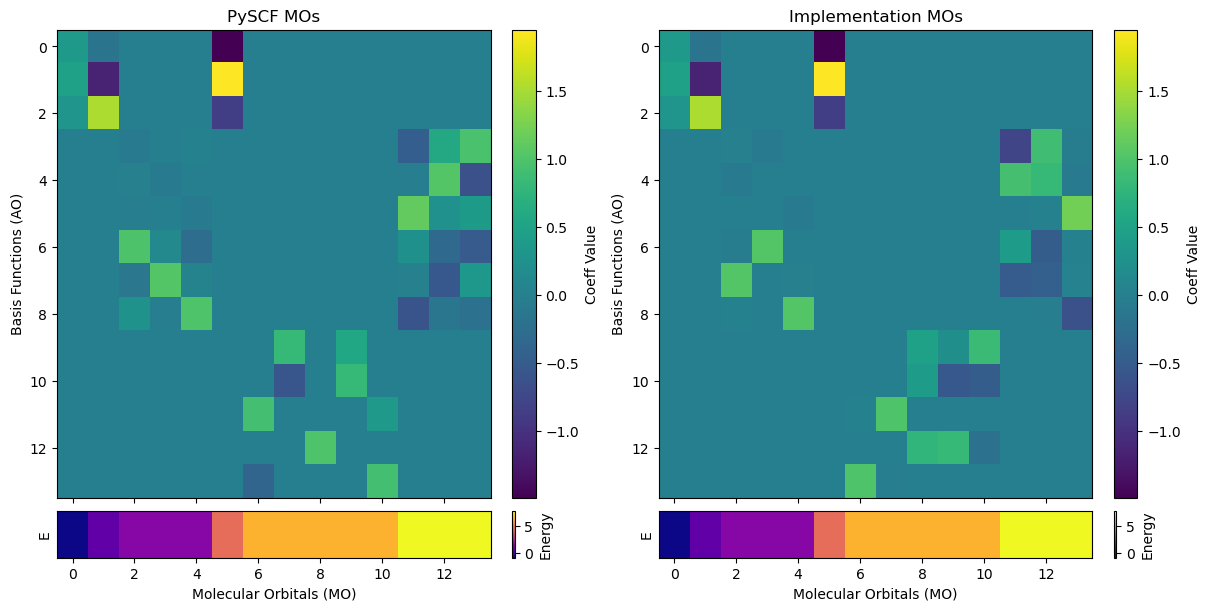

In [180]:
C_pscf = mf.mo_coeff
e_pscf = mf.mo_energy
C_impl = res.R_munu.real
e_impl = res.e_orb.real

plot = plot_mo_analysis(
    C_pscf, e_pscf, C_impl, e_impl, titles=["PySCF MOs", "Implementation MOs"]
)

However, messing around, I have realized that pyscf does not always yield the same MO coefficients. In the $p$ block, sometimes solutions have a matrix shape of:

$$
\begin{pmatrix}
1 & 0.12 & -0.25 \\
-0.12 & 1 & 0.025\\
0.25 & -0.01 & 1 \\
\end{pmatrix}
$$
While some other times it is something like:
$$
\begin{pmatrix}
1.03 & -0.12 &  0.00 \\
0.07 &  0.60 &  0.84 \\
 0.10 &  0.84 & -0.60
\end{pmatrix}
$$
---
So lets see the different MOs for each case:

|Orbital| Pyscf "diagonal"| Pyscf "nondiagonal"| Implementation|
|-|-|-|-|
|$2p1$|![](MO_coefficients/py_diag/2p1.png)|![](MO_coefficients/py_non_diag/2p1.png)|![](MO_coefficients/Me/2p1.png)|
|$2p2$|![](MO_coefficients/py_diag/2p2.png)|![](MO_coefficients/py_non_diag/2p2.png)|![](MO_coefficients/Me/2p2.png)|
|$2p3$|![](MO_coefficients/py_diag/2p3.png)|![](MO_coefficients/py_non_diag/2p3.png)|![](MO_coefficients/Me/2p3.png)|
|$3s1$|![](MO_coefficients/py_diag/3s1.png)|![](MO_coefficients/py_non_diag/3s1.png)|![](MO_coefficients/Me/3s1.png)|
|$4d1$|![](MO_coefficients/py_diag/4d1.png)|![](MO_coefficients/py_non_diag/4d1.png)|![](MO_coefficients/Me/4d1.png)|
|$4d2$|![](MO_coefficients/py_diag/4d2.png)|![](MO_coefficients/py_non_diag/4d2.png)|![](MO_coefficients/Me/4d2.png)|
|$4d3$|![](MO_coefficients/py_diag/4d3.png)|![](MO_coefficients/py_non_diag/4d3.png)|![](MO_coefficients/Me/4d3.png)|
|$4d4$|![](MO_coefficients/py_diag/4d4.png)|![](MO_coefficients/py_non_diag/4d4.png)|![](MO_coefficients/Me/4d4.png)|
|$4d5$|![](MO_coefficients/py_diag/4d5.png)|![](MO_coefficients/py_non_diag/4d5.png)|![](MO_coefficients/Me/4d5.png)|
|$3p1$|![](MO_coefficients/py_diag/3p1.png)|![](MO_coefficients/py_non_diag/3p1.png)|![](MO_coefficients/Me/3p1.png)|
|$3p2$|![](MO_coefficients/py_diag/3p2.png)|![](MO_coefficients/py_non_diag/3p2.png)|![](MO_coefficients/Me/3p2.png)|
|$3p3$|![](MO_coefficients/py_diag/3p3.png)|![](MO_coefficients/py_non_diag/3p3.png)|![](MO_coefficients/Me/3p3.png)|
---
From the previous table, it is possible to see the following:
- $2p$ orbitals:
    - The orbitals, albeit not being defined with the same coefficients, are the same. Their spatial configuration is exactly the same.
- $3s$ orbitals:
    - They are defined in the exact same way and the molecular coefficients are the same. 
- $4d$ orbitals: 
    - The pyscf orbitals in both cases, even though they yield the same correlation energies of $-0.0331375617548947$ in both cases, but the implementation difers in $-0.00035$ Hartree.
    - In the "diagonal" orbitals, there are 3 well defined d orbitals of the type $d_{xy}$, $d_{x^2-y^2}$, $d_{yz}$ or $d_{xz}$ with the two expected nodal planes, while there is one without the second nodal plane well defined. Finally there is a orbital of type $d_{z^2}$, but it is not orientated in the $z$ direction and is not perfectly radial symmetric. 
    - In the case of the "nondiagonal" orbitals, all nodal planes in the $d_{xy}$, $d_{x^2-y^2}$, $d_{yz}$ or $d_{xz}$ orbitals are well defined, but the $d_{z^2}$ orbital is again not oriented in the $z$ direction, but is better defined radially.
    - in the implementation case, only one $d_{xy}$, $d_{x^2-y^2}$, $d_{yz}$ or $d_{xz}$ orbital is well defined, while the rest are a mix of different d orbitals. The $d_{z^2}$ orbital is aligned with the $z$ direction and is radially symmetric.
- $3p$ orbitals:
    - In the "diagonal" and "nondiagonal" case, all $p$ orbitals are mixed, as there is not a pure $3p_x$, $3p_y$ or $3p_z$ orbital.
    - However in the implementation case, the $3p$ orbitals are well separated between a mix of $x$ and $y$ directions independent of the $z$ direction.

---

## Continuation
Therefore, with this in mind, the following questions may be asked:
- If the $2p$ are well defined, what if we limit ourselves to those? Is the correlation energy correct?
- If we restrict us only to $s$ and $p$ functions, is there some error induced by the $d$ shell?
- Can increasing the basis size improve the correlation energy?
- Is occupation relevant in these cases? This comes from previous calculations in other systems that show an error decrease for larger noble gases (with exceptions):

![mp2_error.png](mp2_error.png)

# Truncating the basis

In [181]:
# keep only s and p
sp_only_basis = [b for b in full_basis if b[0] <= 1]

# Basis set limit?

# Occupation?